# Task 1: Problem Definition & Success Metric

**Business Objective:**  
We want to identify individuals earning >50K/year to target for a premium financial product. To avoid wasting marketing budget, we prioritize precision — ensuring that when we contact someone, they are likely to be a high earner.

**Target Variable:**  
income >50K = positive class (1), income <=50K = negative class (0)

**Base Rate:**  
23.93% of individuals earn >50K.

**Chosen Metric:**  
Precision (to minimize false positives and avoid wasted marketing spend).

In [11]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# Load dataset
adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame
print("Data shape:", df.shape)
print(df.head())


Data shape: (48842, 15)
   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-c

In [16]:

df['income'] = df['class'].map({'<=50K': 0, '>50K': 1}).astype(int)

In [17]:
print(df.columns)

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class', 'income'],
      dtype='object')


# Task 2: Data Load & Quick EDA

**Data Source:**  
UCI Adult (Census Income) dataset loaded using `fetch_openml('adult', version=2)`.

**Data Shape:**  
(48,842 rows, 15 columns)

**Key Findings:**
- Class imbalance: 76% earn <=50K, 24% earn >50K.
- Average age: ~38.6 years.
- Most common education: HS-grad, Some-college, Bachelors.
- Capital gain is highly skewed (75% of values are 0).

**Missing Values:**  
Handled by replacing ' ?' with NaN.

**Visualizations:**  
Histograms for numeric features and bar plots for categorical features were created.

Base rate (positive class): 23.93%

Data shape: (48842, 16)

Numeric summaries:
                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  48842.000000  4.884200e+04   48842.000000  48842.000000  48842.000000   
mean      38.643585  1.896641e+05      10.078089   1079.067626     87.502314   
std       13.710510  1.056040e+05       2.570973   7452.019058    403.004552   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.175505e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.781445e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.376420e+05      12.000000      0.000000      0.000000   
max       90.000000  1.490400e+06      16.000000  99999.000000   4356.000000   

       hours-per-week        income  
count    48842.000000  48842.000000  
mean        40.422382      0.239282  
std         12.391444      0.426649  
min          1.000000      0.000000  
25%      

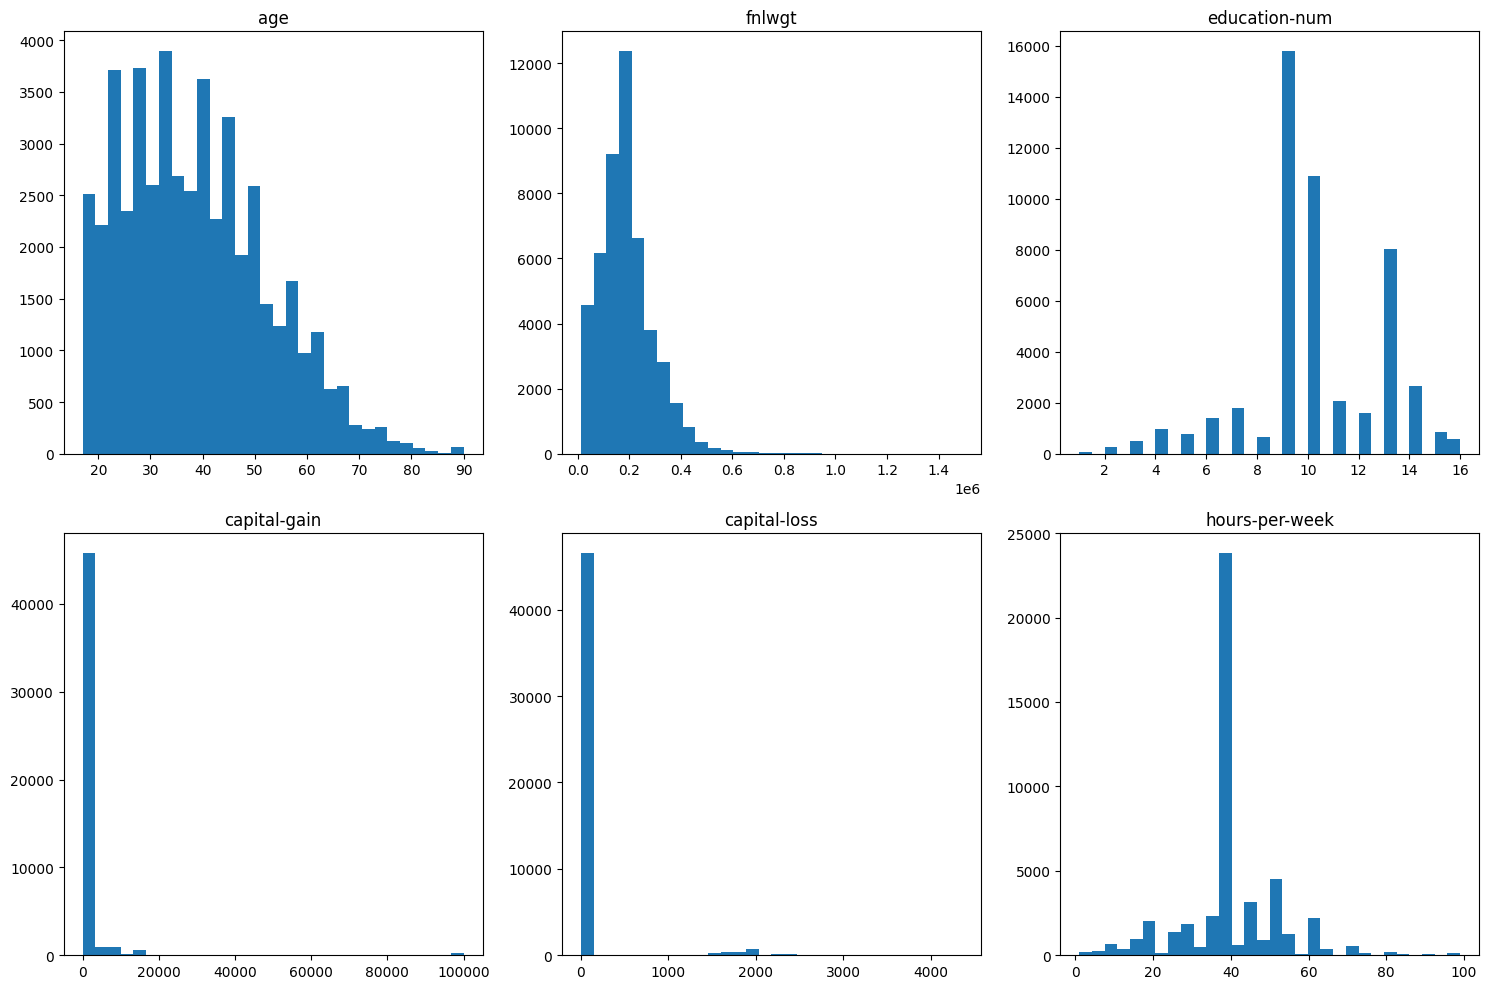

In [10]:

# Target variable — ensure numeric
df['income'] = df['class'].map({'<=50K': 0, '>50K': 1}).astype(int)
base_rate = df['income'].mean()
print(f"Base rate (positive class): {base_rate:.2%}")

# Clean missing values
df = df.replace(' ?', np.nan)

# Quick EDA
print("\nData shape:", df.shape)

# Numeric columns only
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
print("\nNumeric summaries:")
print(numeric_cols.describe())

# Categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts().head())

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
numeric_cols_list = numeric_cols.columns[:6]
for i, col in enumerate(numeric_cols_list):
    row, col_idx = divmod(i, 3)
    axes[row, col_idx].hist(df[col].dropna(), bins=30)
    axes[row, col_idx].set_title(col)

plt.tight_layout()
plt.show()

# Task 3: Create Reproducible Splits

**Why Hold-Out Test is Necessary:**  
A hold-out test set simulates unseen data and gives an unbiased estimate of model performance. If we use it during hyperparameter tuning, we risk overfitting to the test set — making our performance metrics overly optimistic.

**Stratified Split:**  
We use stratified sampling to maintain the same class distribution (76% ≤50K, 24% >50K) in both training and test sets.

**Splits Created:**
- **Train:** 80% of data (used for model training)
- **Dev:** 10% of training data (used for quick experimentation)
- **Test:** 20% of data (used only for final evaluation)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop(['class', 'income'], axis=1)  
y = df['income']

# Encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Stratified hold-out test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Dev set (10% of training)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print(f"Train size: {len(X_train)}")
print(f"Dev size: {len(X_dev)}")
print(f"Test size: {len(X_test)}")

Train size: 35165
Dev size: 3908
Test size: 9769


# Task 4: Implement Simple Baselines

**Purpose:**  
Baselines provide a minimum performance benchmark. Any complex model must outperform these simple baselines to be considered useful.

**Baseline 1: Majority-Class Predictor**  
Always predicts the most frequent class (<=50K). This gives a baseline accuracy of ~76%.

**Baseline 2: Rule-Based Classifier**  
Uses a simple rule: if `education-num >= 13` (college degree or higher), predict >50K; otherwise predict <=50K.

**Evaluation Metrics:**  
- Accuracy  
- Precision  
- Recall  
- F1 Score  
- ROC AUC  
- Confusion Matrix

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Baseline 1: Majority-class predictor
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

# Baseline 2: Rule-based classifier (education-num >= 13)
X_test_rule = X_test['education-num'] >= 13
y_pred_rule = X_test_rule.astype(int)

# Evaluate function
def evaluate_baseline(y_true, y_pred, name):
    print(f"\n{name} Performance:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_true, y_pred):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

# Evaluate both baselines
evaluate_baseline(y_test, y_pred_dummy, "Majority Class Baseline")
evaluate_baseline(y_test, y_pred_rule, "Rule-Based Baseline (education-num >= 13)")


Majority Class Baseline Performance:
Accuracy: 0.7607
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC AUC: 0.5000
Confusion Matrix:
[[7431    0]
 [2338    0]]

Rule-Based Baseline (education-num >= 13) Performance:
Accuracy: 0.7530
Precision: 0.4844
Recall: 0.4970
F1 Score: 0.4906
ROC AUC: 0.6653
Confusion Matrix:
[[6194 1237]
 [1176 1162]]


C:\Users\cfiza\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Task 5: Initial Error Analysis & Next Steps

**Purpose:**  
Analyze the mistakes made by the baseline model to identify patterns and guide feature engineering for the next iteration.

**Error Types:**
- **False Positives (FP):** Model predicted >50K, but actual was ≤50K.
- **False Negatives (FN):** Model predicted ≤50K, but actual was >50K.

**Goal:**  
Find common patterns in FP/FN samples — e.g., age, education, hours-per-week, capital-gain — and list feature issues to fix in Week 2.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a simple model for error analysis
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# False positives and false negatives
fp_indices = np.where((y_pred == 1) & (y_test == 0))[0]
fn_indices = np.where((y_pred == 0) & (y_test == 1))[0]

print(f"False Positives: {len(fp_indices)}")
print(f"False Negatives: {len(fn_indices)}")

# Sample false positives
print("\nSample False Positives (predicted >50K, actual ≤50K):")
sample_fp = X_test.iloc[fp_indices[:10]][['age', 'education-num', 'hours-per-week', 'capital-gain', 'marital-status_Married-civ-spouse']]
print(sample_fp)

# Sample false negatives
print("\nSample False Negatives (predicted ≤50K, actual >50K):")
sample_fn = X_test.iloc[fn_indices[:10]][['age', 'education-num', 'hours-per-week', 'capital-gain', 'marital-status_Married-civ-spouse']]
print(sample_fn)

# Pattern analysis
print("\nCommon patterns in False Positives:")
print(f"Average age: {X_test.iloc[fp_indices]['age'].mean():.1f}")
print(f"Average education-num: {X_test.iloc[fp_indices]['education-num'].mean():.1f}")
print(f"Average hours-per-week: {X_test.iloc[fp_indices]['hours-per-week'].mean():.1f}")

print("\nCommon patterns in False Negatives:")
print(f"Average age: {X_test.iloc[fn_indices]['age'].mean():.1f}")
print(f"Average education-num: {X_test.iloc[fn_indices]['education-num'].mean():.1f}")
print(f"Average hours-per-week: {X_test.iloc[fn_indices]['hours-per-week'].mean():.1f}")

# Feature issues
print("\nFeature Issues to Fix in Week 2:")
print("1. Missing values in workclass, occupation, native-country")
print("2. Skewed features: capital-gain (75% zeros), capital-loss")
print("3. High-cardinality categorical: occupation, native-country")
print("4. Outliers in hours-per-week (max 99 hours)")

False Positives: 477
False Negatives: 949

Sample False Positives (predicted >50K, actual ≤50K):
       age  education-num  hours-per-week  capital-gain  \
524     53             10              50             0   
38546   42             16              40             0   
44616   35             13              40             0   
25506   28             12              40             0   
784     49              9              40          4064   
18011   24             14              90          6849   
31262   32             13              44             0   
34560   72              9              50             0   
34231   57              9              40             0   
2963    57             10              84             0   

       marital-status_Married-civ-spouse  
524                                 True  
38546                               True  
44616                               True  
25506                               True  
784                                 Tr